In [1]:
import pandas as pd
import numpy as np

In [2]:
calendar = pd.read_csv("C:\\Users\\AHMAD\\Desktop\\data final project colledge\\Depi M5\\data\\raw\\calendar.csv")

sales = pd.read_csv("C:\\Users\\AHMAD\\Desktop\\data final project colledge\\Depi M5\\data\\raw\\sales_train_evaluation.csv")

prices = pd.read_csv("C:\\Users\\AHMAD\\Desktop\\data final project colledge\\Depi M5\\data\\raw\\sell_prices.csv")

In [4]:
# Keep metadata columns
id_columns = sales.columns[:6]

# Keep the last 1,095 daily sales columns
sales_columns = sales.columns[-1095:]

# Create a smaller dataset
sales = sales[list(id_columns) + list(sales_columns)]

sales.shape

(30490, 1101)

In [5]:
sales_long = sales.melt(
    id_vars=id_columns,
    var_name="d",
    value_name="sales"
)

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_847,1
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_847,2
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_847,1


In [6]:
sales_long.shape

(33386550, 8)

In [7]:
sales_long = sales_long.merge(
    calendar,
    on="d",
    how="left"
)

In [8]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,7,5,2013,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_847,1,2013-05-24,11317,...,7,5,2013,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,7,5,2013,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_847,2,2013-05-24,11317,...,7,5,2013,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_847,1,2013-05-24,11317,...,7,5,2013,NaN,NaN,NaN,NaN,0,0,0


In [9]:
sales_long.shape

(33386550, 21)

In [10]:
sales_long = sales_long.merge(
    prices,
    on=["item_id", "store_id", "wm_yr_wk"],
    how="left"
)

In [11]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_847,1,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,3.97
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_847,2,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,4.64
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_847,1,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,3.08


In [12]:
sales_long.shape

(33386550, 22)

In [13]:
sales_long["sell_price"].isnull().sum()

np.int64(2126974)

In [14]:
round(
    sales_long["sell_price"].isnull().mean() * 100,
    2
)

np.float64(6.37)

In [15]:
sales_long[sales_long["sell_price"].isnull()].head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
25,HOBBIES_1_026_CA_1_evaluation,HOBBIES_1_026,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
26,HOBBIES_1_027_CA_1_evaluation,HOBBIES_1_027,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
32,HOBBIES_1_033_CA_1_evaluation,HOBBIES_1_033,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
44,HOBBIES_1_045_CA_1_evaluation,HOBBIES_1_045,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
45,HOBBIES_1_046_CA_1_evaluation,HOBBIES_1_046,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
53,HOBBIES_1_054_CA_1_evaluation,HOBBIES_1_054,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
60,HOBBIES_1_062_CA_1_evaluation,HOBBIES_1_062,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN
64,HOBBIES_1_066_CA_1_evaluation,HOBBIES_1_066,HOBBIES_1,HOBBIES,CA_1,CA,d_847,0,2013-05-24,11317,...,5,2013,NaN,NaN,NaN,NaN,0,0,0,NaN


In [16]:
prices[
    (prices["item_id"] == "HOBBIES_1_001") &
    (prices["store_id"] == "CA_1") &
    (prices["wm_yr_wk"] == 11317)
]

,store_id,item_id,wm_yr_wk,sell_price


In [17]:
prices[
    (prices["item_id"] == "HOBBIES_1_001") &
    (prices["store_id"] == "CA_1")
].head(10)

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
5,CA_1,HOBBIES_1_001,11330,8.26
6,CA_1,HOBBIES_1_001,11331,8.26
7,CA_1,HOBBIES_1_001,11332,8.26
8,CA_1,HOBBIES_1_001,11333,8.26
9,CA_1,HOBBIES_1_001,11334,8.26


In [18]:
prices[
    (prices["item_id"] == "HOBBIES_1_001") &
    (prices["store_id"] == "CA_1")
].tail(10)

,store_id,item_id,wm_yr_wk,sell_price
144,CA_1,HOBBIES_1_001,11612,8.38
145,CA_1,HOBBIES_1_001,11613,8.38
146,CA_1,HOBBIES_1_001,11614,8.38
147,CA_1,HOBBIES_1_001,11615,8.38
148,CA_1,HOBBIES_1_001,11616,8.38
149,CA_1,HOBBIES_1_001,11617,8.38
150,CA_1,HOBBIES_1_001,11618,8.38
151,CA_1,HOBBIES_1_001,11619,8.38
152,CA_1,HOBBIES_1_001,11620,8.38
153,CA_1,HOBBIES_1_001,11621,8.38


### Merge with Price Data

- Merged on: `item_id`, `store_id`, and `wm_yr_wk`.
- Added the `sell_price` column.
- Approximately 6.37% of `sell_price` values are missing.
- Investigation confirmed that these missing values already existed in the original dataset (e.g., before the first recorded price for some products). Therefore, no imputation was performed at this stage.

In [19]:
sales_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 33386550 entries, 0 to 33386549
Data columns (total 22 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            str    
 1   item_id       str    
 2   dept_id       str    
 3   cat_id        str    
 4   store_id      str    
 5   state_id      str    
 6   d             str    
 7   sales         int64  
 8   date          str    
 9   wm_yr_wk      int64  
 10  weekday       str    
 11  wday          int64  
 12  month         int64  
 13  year          int64  
 14  event_name_1  str    
 15  event_type_1  str    
 16  event_name_2  str    
 17  event_type_2  str    
 18  snap_CA       int64  
 19  snap_TX       int64  
 20  snap_WI       int64  
 21  sell_price    float64
dtypes: float64(1), int64(8), str(13)
memory usage: 8.2 GB


In [20]:
sales_long["date"] = pd.to_datetime(sales_long["date"])

In [22]:
sales_long["date"].dtype

dtype('<M8[us]')

In [23]:
sales_long.sample(1, random_state=42)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
4275670,HOUSEHOLD_1_417_CA_3_evaluation,HOUSEHOLD_1_417,HOUSEHOLD_1,HOUSEHOLD,CA_3,CA,d_987,2,2013-10-11,11337,...,10,2013,NaN,NaN,NaN,NaN,0,1,1,5.48


In [24]:
memory_before = sales_long.memory_usage(deep=True).sum() / 1024**3
print(f"Memory Usage Before Optimization: {memory_before:.2f} GB")

Memory Usage Before Optimization: 7.91 GB


In [25]:
sales_long.describe().T

,count,mean,min,25%,50%,75%,max,std
sales,33386550.0,1.228946,0.0,0.0,0.0,1.0,763.0,3.793185
date,33386550,2014-11-22 00:00:00,2013-05-24 00:00:00,2014-02-21 00:00:00,2014-11-22 00:00:00,2015-08-23 00:00:00,2016-05-22 00:00:00,NaN
wm_yr_wk,33386550.0,11457.663014,11317.0,11403.0,11443.0,11530.0,11617.0,88.886757
wday,33386550.0,3.998174,1.0,2.0,4.0,6.0,7.0,2.002281
month,33386550.0,6.523288,1.0,4.0,7.0,10.0,12.0,3.450254
year,33386550.0,2014.391781,2013.0,2014.0,2014.0,2015.0,2016.0,0.951291
snap_CA,33386550.0,0.328767,0.0,0.0,0.0,1.0,1.0,0.469765
snap_TX,33386550.0,0.328767,0.0,0.0,0.0,1.0,1.0,0.469765
snap_WI,33386550.0,0.328767,0.0,0.0,0.0,1.0,1.0,0.469765
sell_price,31259576.0,4.44537,0.01,2.18,3.47,5.86,107.32,3.500928


In [26]:
sales_long.to_parquet(
    "../data/processed/sales_long.parquet",
    index=False
)

In [27]:
import pandas as pd

check = pd.read_parquet("../data/processed/sales_long.parquet")

check.shape

(33386550, 22)

# Create Analysis Tables

## Goal

Create lightweight aggregated datasets for Exploratory Data Analysis (EDA) and the Streamlit dashboard.

Instead of repeatedly loading the full processed dataset (33 million+ rows), these summary tables provide fast access to key business metrics while reducing memory usage and improving performance.

In [28]:
monthly_sales = (
    sales_long
    .groupby(["year", "month"], as_index=False)
    .agg(total_sales=("sales", "sum"))
)

monthly_sales.head()

,year,month,total_sales
0,2013,5,267026
1,2013,6,1135593
2,2013,7,1159467
3,2013,8,1204813
4,2013,9,1166515


In [29]:
monthly_sales.shape

(37, 3)

In [31]:
monthly_sales.to_parquet(
    "../data/analysis/monthly_sales.parquet",
    index=False
)

### Monthly Sales Table

**Business Question**

How do total sales change from month to month?

**Method**

- Grouped the processed dataset by `year` and `month`.
- Calculated the total sales for each month by summing the `sales` column.

**Output**

Created `monthly_sales.parquet`, which will be used for:
- Monthly trend analysis.
- Seasonal pattern visualization.
- Streamlit dashboard.

In [32]:
category_sales = (
    sales_long
    .groupby("cat_id", as_index=False)
    .agg(total_sales=("sales", "sum"))
    .sort_values("total_sales", ascending=False)
)

category_sales

,cat_id,total_sales
0,FOODS,27616083
2,HOUSEHOLD,9518699
1,HOBBIES,3895486


In [33]:
category_sales.shape

(3, 2)

In [34]:
category_sales.to_parquet(
    "../data/analysis/category_sales.parquet",
    index=False
)

### Category Sales Data Mart

**Business Question**

Which product category contributes the most to total sales?

**Method**

- Grouped the processed dataset by `cat_id`.
- Calculated the total sales for each category.
- Sorted the results in descending order.

**Output**

Created `category_sales.parquet` for category comparison in the EDA notebook and Streamlit dashboard.

In [35]:
store_sales = (
    sales_long
    .groupby(["state_id", "store_id"], as_index=False)
    .agg(total_sales=("sales", "sum"))
    .sort_values("total_sales", ascending=False)
)

store_sales

,state_id,store_id,total_sales
2,CA,CA_3,6919055
0,CA,CA_1,4809909
8,WI,WI_2,4561984
5,TX,TX_2,4220301
6,TX,TX_3,3840394
7,WI,WI_1,3608841
1,CA,CA_2,3544360
9,WI,WI_3,3506042
4,TX,TX_1,3406048
3,CA,CA_4,2613334


In [36]:
store_sales.shape

(10, 3)

In [37]:
store_sales.to_parquet(
    "../data/analysis/store_sales.parquet",
    index=False
)

### Store Sales Data Mart

**Business Question**

Which Walmart stores generate the highest total sales?

**Method**

- Grouped the processed dataset by `state_id` and `store_id`.
- Calculated the total sales for each store.
- Sorted the results in descending order.

**Output**

Created `store_sales.parquet` for store performance analysis in the EDA notebook and Streamlit dashboard.

In [38]:
state_sales = (
    sales_long
    .groupby("state_id", as_index=False)
    .agg(total_sales=("sales", "sum"))
    .sort_values("total_sales", ascending=False)
)

state_sales

,state_id,total_sales
0,CA,17886658
2,WI,11676867
1,TX,11466743


In [39]:
state_sales.shape

(3, 2)

In [40]:
state_sales.to_parquet(
    "../data/analysis/state_sales.parquet",
    index=False
)

### State Sales Data Mart

**Business Question**

Which state contributes the most to total sales?

**Method**

- Grouped the processed dataset by `state_id`.
- Calculated the total sales for each state.
- Sorted the results in descending order.

**Output**

Created `state_sales.parquet` for state-level analysis in the EDA notebook and Streamlit dashboard.

In [41]:
department_sales = (
    sales_long
    .groupby(["cat_id", "dept_id"], as_index=False)
    .agg(total_sales=("sales", "sum"))
    .sort_values("total_sales", ascending=False)
)

department_sales

,cat_id,dept_id,total_sales
2,FOODS,FOODS_3,19690227
5,HOUSEHOLD,HOUSEHOLD_1,7638252
1,FOODS,FOODS_2,4762647
3,HOBBIES,HOBBIES_1,3530387
0,FOODS,FOODS_1,3163209
6,HOUSEHOLD,HOUSEHOLD_2,1880447
4,HOBBIES,HOBBIES_2,365099


In [42]:
department_sales.shape

(7, 3)

In [ ]:
department_sales.to_parquet(
    "../data/analysis/department_sales.parquet",
    index=False
)

### Department Sales Data Mart

**Business Question**

Which product departments generate the highest total sales?

**Method**

- Grouped the processed dataset by `cat_id` and `dept_id`.
- Calculated the total sales for each department.
- Sorted the results in descending order.

**Output**

Created `department_sales.parquet` for department-level analysis in the EDA notebook and Streamlit dashboard.

In [41]:
weekday_sales = (
    sales_long
    .groupby(["wday", "weekday"], as_index=False)
    .agg(total_sales=("sales", "sum"))
    .sort_values("wday")
)

weekday_sales

,wday,weekday,total_sales
0,1,Saturday,7064159
1,2,Sunday,7095934
2,3,Monday,5612686
3,4,Tuesday,5201675
4,5,Wednesday,5108961
5,6,Thursday,5136327
6,7,Friday,5810526


In [42]:
weekday_sales.to_parquet(
    "../data/analysis/weekday_sales.parquet",
    index=False
)

### Weekday Sales Data Mart

**Business Question**

How do total sales vary across different days of the week?

**Method**

- Grouped the processed dataset by `wday` and `weekday`.
- Calculated the total sales for each weekday.
- Sorted by `wday` to preserve chronological order.

**Output**

Created `weekday_sales.parquet` for weekday trend analysis in the EDA notebook and Streamlit dashboard.

# Create Modeling Dataset

To enable efficient model training on the available hardware, a modeling dataset is created using only the highest-performing store (CA_3). This significantly reduces memory usage while preserving the forecasting workflow.

In [44]:
ca3_sales = sales_long[
    sales_long["store_id"] == "CA_3"
].copy()

ca3_sales.shape

(3338655, 22)

In [51]:
import pandas as pd
import numpy as np

# Select numeric columns only
numeric_cols = ca3_sales.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:

    Q1 = ca3_sales[col].quantile(0.25)
    Q3 = ca3_sales[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ca3_sales[
        (ca3_sales[col] < lower_bound) |
        (ca3_sales[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Outliers": len(outliers),
        "Percentage": round(len(outliers) / len(ca3_sales) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    by="Percentage",
    ascending=False
)

,Feature,Outliers,Percentage
0,sales,309100,9.26
8,sell_price,142582,4.27
1,wm_yr_wk,0,0.00
3,month,0,0.00
2,wday,0,0.00
4,year,0,0.00
5,snap_CA,0,0.00
6,snap_TX,0,0.00
7,snap_WI,0,0.00


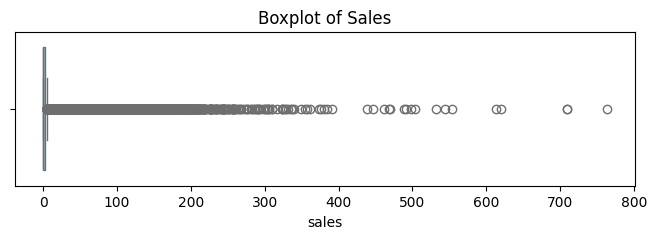

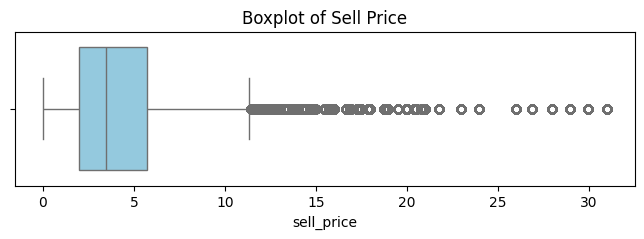

In [53]:

plt.figure(figsize=(8,2))
sns.boxplot(x=ca3_sales['sales'], color='skyblue')
plt.title("Boxplot of Sales")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=ca3_sales['sell_price'], color='skyblue')
plt.title("Boxplot of Sell Price")
plt.show()